# Capítulo 22 — Gradient Boosting

En el capítulo anterior construimos un Random Forest: muchos árboles diversos se entrenaban de manera relativamente independiente y luego combinaban sus respuestas. **Gradient Boosting** también reúne árboles, pero cambia por completo la lógica del ensamble.

Ahora los árboles se construyen en secuencia. Cada uno agrega una corrección a la predicción acumulada y trata de mejorar lo que los anteriores todavía no resolvieron bien. La potencia del modelo aparece al sumar muchas contribuciones pequeñas.

Primero observaremos esta idea en regresión, donde las correcciones resultan fáciles de seguir. Después retomaremos **Breast Cancer Wisconsin** para comparar Gradient Boosting con un árbol individual y con Random Forest. Reservaremos nuevamente un conjunto de prueba final y tomaremos todas las decisiones mediante validación dentro del conjunto de desarrollo.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar la construcción secuencial y aditiva de Gradient Boosting;
- interpretar una predicción inicial y las correcciones posteriores;
- diferenciar la lógica de boosting de la lógica de Random Forest;
- comparar los tres modelos usando exactamente los mismos folds;
- relacionar `n_estimators` con `learning_rate`;
- reconocer el efecto de la profundidad, las hojas y `subsample`;
- identificar subajuste y sobreajuste durante las etapas del ensamble;
- elegir una configuración sin consultar el test final;
- reconocer distintas implementaciones de Gradient Boosting;
- evaluar el modelo con prudencia.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para organizar los datos, Matplotlib para crear gráficos y `scikit-learn` para entrenar modelos y realizar evaluaciones reproducibles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_breast_cancer,
    make_classification,
)
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.dpi"] = 110


## 2. Construir una predicción mediante correcciones

Comenzaremos con diez viviendas. Usaremos solamente la superficie para predecir el precio. Los datos son didácticos: permiten ver una relación general creciente y un cambio importante a partir de determinadas superficies.


In [2]:
superficie = np.array(
    [35, 45, 55, 65, 75, 85, 95, 110, 125, 140],
    dtype=float,
)
precio = np.array(
    [
        62000, 73000, 82000, 93000, 101000,
        113000, 160000, 176000, 193000, 211000,
    ],
    dtype=float,
)

X_reg = superficie.reshape(-1, 1)
y_reg = precio

viviendas = pd.DataFrame({
    "superficie_m2": superficie,
    "precio": precio,
})
viviendas


,superficie_m2,precio
0,35.0,62000.0
1,45.0,73000.0
2,55.0,82000.0
3,65.0,93000.0
4,75.0,101000.0
5,85.0,113000.0
6,95.0,160000.0
7,110.0,176000.0
8,125.0,193000.0
9,140.0,211000.0


In [3]:
modelo_reg = GradientBoostingRegressor(
    n_estimators=4,
    learning_rate=0.5,
    max_depth=1,
    loss="squared_error",
    random_state=42,
)
modelo_reg.fit(X_reg, y_reg)

prediccion_inicial = modelo_reg.init_.predict(X_reg)
predicciones_por_etapa = list(
    modelo_reg.staged_predict(X_reg)
)

pd.DataFrame({
    "modelo": [
        "Predicción inicial",
        "Después del árbol 1",
        "Después del árbol 2",
        "Después del árbol 3",
        "Después del árbol 4",
    ],
    "MAE_entrenamiento": [
        mean_absolute_error(y_reg, prediccion_inicial),
        *[
            mean_absolute_error(y_reg, prediccion)
            for prediccion in predicciones_por_etapa
        ],
    ],
}).round(2)


,modelo,MAE_entrenamiento
0,Predicción inicial,46880.00
1,Después del árbol 1,24666.67
2,Después del árbol 2,16473.33
3,Después del árbol 3,11920.83
4,Después del árbol 4,8438.39


Antes de agregar árboles, el modelo usa una predicción constante de `$126.400`, que coincide con el precio promedio. Su MAE es `$46.880`.

Cada árbol pequeño agrega una corrección. Después de cuatro etapas, el MAE de entrenamiento baja a aproximadamente `$8.438`. El modelo no reemplaza lo aprendido en cada paso: conserva la predicción acumulada y suma un nuevo aporte.


In [4]:
errores_tras_inicio = (
    y_reg - prediccion_inicial
)
correccion_bruta_arbol_1 = (
    modelo_reg.estimators_[0, 0].predict(X_reg)
)

pd.DataFrame({
    "superficie_m2": superficie,
    "error_tras_inicio": errores_tras_inicio,
    "correccion_aprendida": (
        correccion_bruta_arbol_1
    ),
    "aporte_con_learning_rate": (
        modelo_reg.learning_rate
        * correccion_bruta_arbol_1
    ),
}).round(2)


,superficie_m2,error_tras_inicio,correccion_aprendida,aporte_con_learning_rate
0,35.0,-64400.0,-39066.67,-19533.33
1,45.0,-53400.0,-39066.67,-19533.33
2,55.0,-44400.0,-39066.67,-19533.33
3,65.0,-33400.0,-39066.67,-19533.33
4,75.0,-25400.0,-39066.67,-19533.33
5,85.0,-13400.0,-39066.67,-19533.33
6,95.0,33600.0,58600.00,29300.00
7,110.0,49600.0,58600.00,29300.00
8,125.0,66600.0,58600.00,29300.00
9,140.0,84600.0,58600.00,29300.00


El primer árbol intenta aproximar los errores que dejó la predicción inicial. Como su profundidad es `1`, no puede memorizar un ajuste diferente para cada vivienda: agrupa casos y aprende una corrección simple para cada lado de un único corte.

La columna `correccion_aprendida` muestra esa aproximación. El aporte que efectivamente se suma es menor porque `learning_rate=0.5` reduce cada corrección a la mitad. El siguiente árbol trabajará con los errores que queden después de ese aporte.


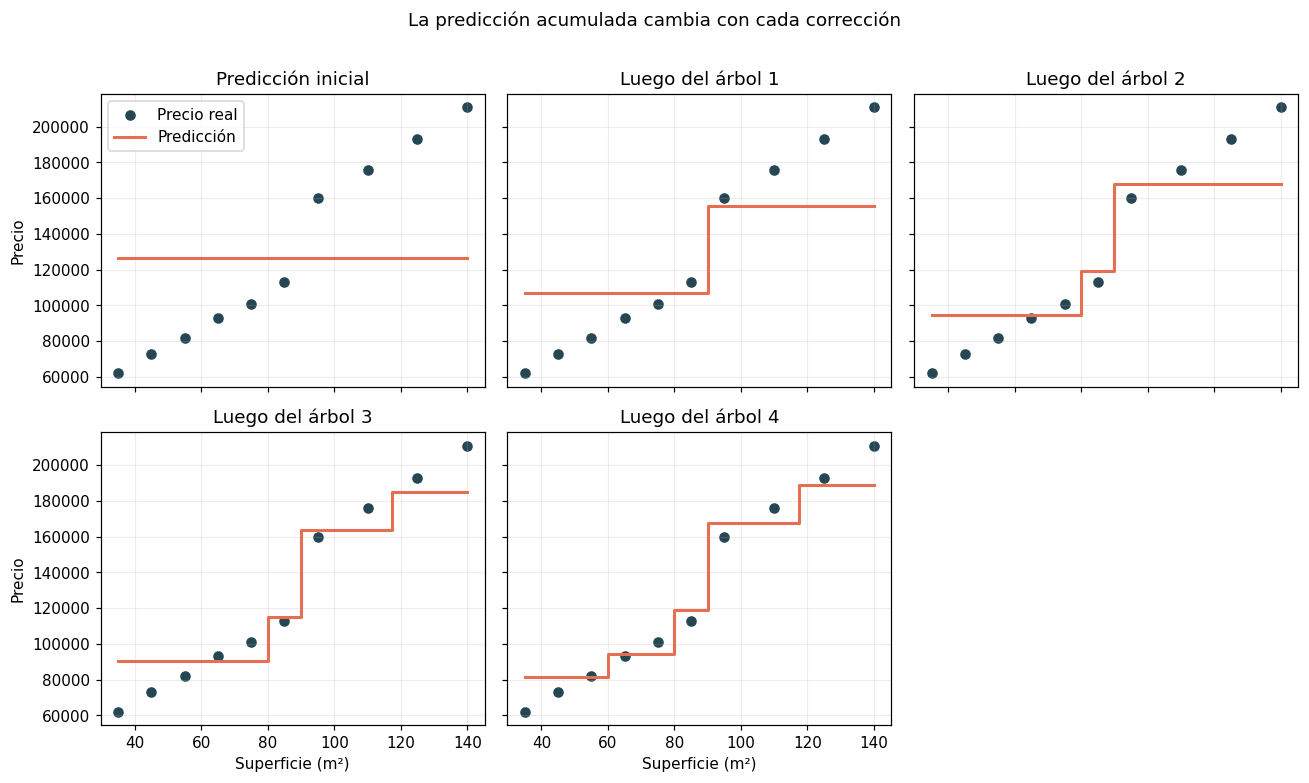

In [5]:
predicciones_grafico = [
    prediccion_inicial,
    *predicciones_por_etapa,
]
titulos = [
    "Predicción inicial",
    "Luego del árbol 1",
    "Luego del árbol 2",
    "Luego del árbol 3",
    "Luego del árbol 4",
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 7),
    sharex=True,
    sharey=True,
)

for ax, prediccion, titulo in zip(
    axes.flat,
    predicciones_grafico,
    titulos,
):
    ax.scatter(
        superficie,
        precio,
        color="#264653",
        s=35,
        label="Precio real",
    )
    ax.step(
        superficie,
        prediccion,
        where="mid",
        color="#E76F51",
        linewidth=2,
        label="Predicción",
    )
    ax.set_title(titulo)
    ax.grid(alpha=0.22)

axes.flat[-1].axis("off")
axes[1, 0].set_xlabel("Superficie (m²)")
axes[1, 1].set_xlabel("Superficie (m²)")
axes[0, 0].set_ylabel("Precio")
axes[1, 0].set_ylabel("Precio")
axes[0, 0].legend()

fig.suptitle(
    "La predicción acumulada cambia con cada corrección",
    y=1.01,
)
plt.tight_layout()
plt.show()


Los árboles de profundidad `1` producen correcciones muy simples. Sin embargo, la suma de varias reglas escalonadas representa una relación bastante más rica que cualquiera de ellas por separado.

El gráfico muestra el aprendizaje sobre los mismos datos usados para entrenar. Que el error disminuya en estas diez viviendas no alcanza para afirmar que también disminuirá en casos nuevos. Más adelante veremos qué ocurre al observar entrenamiento y validación por separado.


## 3. Reconstruir una predicción

Tomemos la vivienda de `110 m²`. En regresión con pérdida cuadrática, podemos reconstruir la predicción como la suma de una estimación inicial y las contribuciones de los árboles, multiplicadas por `learning_rate`.


In [6]:
indice_caso = 7
X_caso = X_reg[[indice_caso]]

aportes = [
    modelo_reg.learning_rate
    * arbol[0].predict(X_caso)[0]
    for arbol in modelo_reg.estimators_
]

predicciones_acumuladas = [
    prediccion_inicial[indice_caso],
    *(
        prediccion_inicial[indice_caso]
        + np.cumsum(aportes)
    ),
]

detalle_aportes = pd.DataFrame({
    "etapa": [
        "Predicción inicial",
        "Árbol 1",
        "Árbol 2",
        "Árbol 3",
        "Árbol 4",
    ],
    "aporte": [
        prediccion_inicial[indice_caso],
        *aportes,
    ],
    "prediccion_acumulada": predicciones_acumuladas,
})

detalle_aportes.round(2)


,etapa,aporte,prediccion_acumulada
0,Predicción inicial,126400.00,126400.00
1,Árbol 1,29300.00,155700.00
2,Árbol 2,12333.33,168033.33
3,Árbol 3,-4245.83,163787.50
4,Árbol 4,3847.32,167634.82


Para la vivienda de `110 m²`, el modelo parte de `$126.400`. Los dos primeros árboles elevan con fuerza la estimación; el tercero realiza una corrección negativa y el cuarto vuelve a aumentarla. La suma llega a `$167.634,82`, exactamente el mismo valor que entrega `predict()`.

No debemos interpretar un árbol aislado como una predicción completa. Su significado depende de todo lo acumulado antes y de la tasa de aprendizaje. Esta dependencia secuencial distingue a Gradient Boosting de Random Forest.


## 4. Preparar el problema de clasificación

Retomaremos Breast Cancer Wisconsin. La variable objetivo original usa `0` para maligno y `1` para benigno. La invertiremos para conservar la convención de los cuadernos anteriores:

- `1`: caso maligno;
- `0`: caso benigno.

> Este conjunto se utiliza con fines didácticos. Un modelo construido aquí no constituye una herramienta clínica.


In [7]:
datos_medicos = load_breast_cancer(as_frame=True)

X = datos_medicos.data.copy()
y = 1 - datos_medicos.target
y.name = "caso_maligno"

pd.DataFrame({
    "filas": [len(X)],
    "variables": [X.shape[1]],
    "casos_benignos": [(y == 0).sum()],
    "casos_malignos": [(y == 1).sum()],
    "proporcion_malignos": [y.mean()],
}).round(3)


,filas,variables,casos_benignos,casos_malignos,proporcion_malignos
0,569,30,357,212,0.373


Todas las variables son numéricas. Los modelos basados en árboles no necesitan escalado para comparar valores con umbrales, aunque un dataset real todavía podría requerir imputación, codificación de categorías u otras transformaciones.


## 5. Reservar el conjunto de prueba final

Separaremos el mismo 20% usado en el Cuaderno 21. Las comparaciones y las decisiones se realizarán dentro del conjunto de desarrollo. El test permanecerá reservado hasta la evaluación definitiva.


In [8]:
X_desarrollo, X_test_final, y_desarrollo, y_test_final = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=21,
        stratify=y,
    )
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [len(X_desarrollo), len(X_test_final)],
    "proporcion_malignos": [
        y_desarrollo.mean(),
        y_test_final.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


Hasta la sección final no consultaremos ninguna métrica del test. Usarlo para elegir la cantidad de árboles, la tasa de aprendizaje o la profundidad lo convertiría en parte del proceso de ajuste y dejaría de ser una prueba independiente.


## 6. Comparar un árbol, un bosque y boosting

Usaremos exactamente los mismos cinco folds para los tres modelos. Mediremos F1 porque la clase positiva es el caso maligno y queremos considerar conjuntamente falsas alarmas y casos no detectados. También conservaremos accuracy como referencia.

Las configuraciones de Random Forest y Gradient Boosting son puntos de partida, no modelos exhaustivamente optimizados.


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

modelos = {
    "Árbol individual": DecisionTreeClassifier(
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
    ),
}

resultados_cv = {}

for nombre, modelo in modelos.items():
    resultados_cv[nombre] = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
        return_train_score=True,
        n_jobs=-1,
    )


In [10]:
filas_comparacion = []

for nombre, resultados in resultados_cv.items():
    filas_comparacion.append({
        "modelo": nombre,
        "F1_entrenamiento": (
            resultados["train_f1"].mean()
        ),
        "F1_validacion": (
            resultados["test_f1"].mean()
        ),
        "desviacion_F1": (
            resultados["test_f1"].std()
        ),
        "accuracy_validacion": (
            resultados["test_accuracy"].mean()
        ),
    })

comparacion_modelos = pd.DataFrame(
    filas_comparacion
)
comparacion_modelos.round(4)


,modelo,F1_entrenamiento,F1_validacion,desviacion_F1,accuracy_validacion
0,Árbol individual,1.0,0.8869,0.0571,0.9187
1,Random Forest,1.0,0.9440,0.0422,0.9582
2,Gradient Boosting,1.0,0.9431,0.0305,0.9582


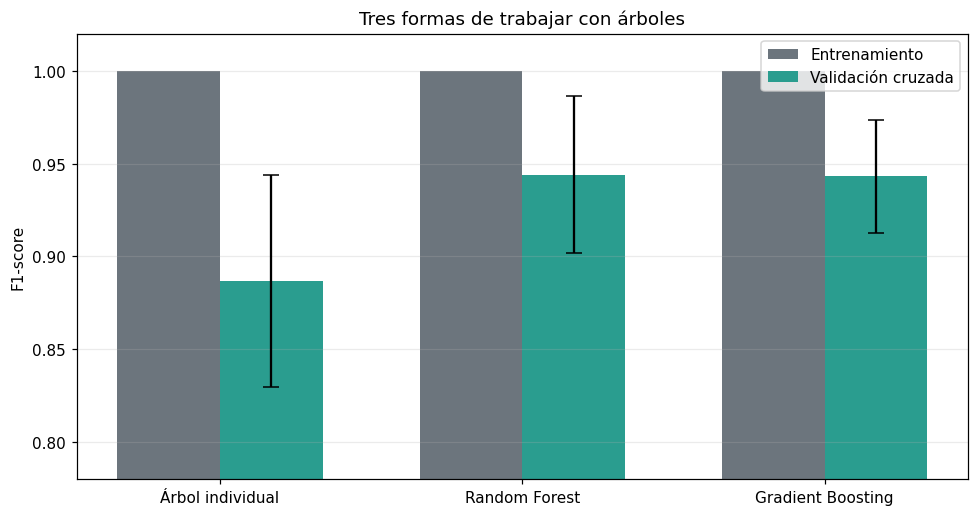

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.8))

x = np.arange(len(comparacion_modelos))
ancho = 0.34

ax.bar(
    x - ancho / 2,
    comparacion_modelos["F1_entrenamiento"],
    width=ancho,
    color="#6C757D",
    label="Entrenamiento",
)
ax.bar(
    x + ancho / 2,
    comparacion_modelos["F1_validacion"],
    width=ancho,
    yerr=comparacion_modelos["desviacion_F1"],
    capsize=5,
    color="#2A9D8F",
    label="Validación cruzada",
)

ax.set_xticks(x)
ax.set_xticklabels(comparacion_modelos["modelo"])
ax.set_ylim(0.78, 1.02)
ax.set_ylabel("F1-score")
ax.set_title(
    "Tres formas de trabajar con árboles"
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


El árbol individual alcanza F1 `1,000` en entrenamiento, pero baja a `0,887` en validación. Random Forest obtiene `0,944` y Gradient Boosting `0,943`. En esta configuración inicial, los dos ensambles quedan prácticamente empatados y superan al árbol aislado.

La semejanza de los resultados no implica que ambos aprendan de la misma manera. El bosque combina árboles diversos; boosting construye una secuencia de correcciones. Tampoco prueba que uno sea siempre superior: el orden podría cambiar con otros datos, divisiones, métricas o hiperparámetros.


## 7. Relacionar `learning_rate` con `n_estimators`

La tasa de aprendizaje controla cuánto aporta cada árbol. Una tasa pequeña produce correcciones suaves y suele necesitar más etapas. Una tasa alta avanza más rápido, pero puede pasarse del punto útil.

Compararemos dieciséis combinaciones mediante los mismos folds. Mantendremos árboles pequeños de profundidad `2` para concentrarnos en la interacción entre los dos hiperparámetros.


In [12]:
tasas_aprendizaje = [0.02, 0.05, 0.10, 0.20]
cantidades_arboles = [25, 50, 100, 200]

filas_tasa_estimadores = []

for tasa in tasas_aprendizaje:
    for cantidad in cantidades_arboles:
        modelo = GradientBoostingClassifier(
            n_estimators=cantidad,
            learning_rate=tasa,
            max_depth=2,
            random_state=42,
        )
        resultados = cross_validate(
            modelo,
            X_desarrollo,
            y_desarrollo,
            cv=cv,
            scoring="f1",
            return_train_score=True,
            n_jobs=-1,
        )

        filas_tasa_estimadores.append({
            "learning_rate": tasa,
            "n_estimators": cantidad,
            "F1_entrenamiento": (
                resultados["train_score"].mean()
            ),
            "F1_validacion": (
                resultados["test_score"].mean()
            ),
            "desviacion_F1": (
                resultados["test_score"].std()
            ),
        })

resultados_tasa_estimadores = pd.DataFrame(
    filas_tasa_estimadores
)
resultados_tasa_estimadores.round(4)


,learning_rate,n_estimators,F1_entrenamiento,F1_validacion,desviacion_F1
0,0.02,25,0.9437,0.8972,0.0303
1,0.02,50,0.9623,0.9251,0.0387
2,0.02,100,0.9775,0.9342,0.0399
3,0.02,200,0.9911,0.9381,0.0442
4,0.05,25,0.9653,0.9282,0.0426
5,0.05,50,0.9866,0.9349,0.0401
6,0.05,100,0.9956,0.9381,0.0442
7,0.05,200,1.0000,0.9462,0.0241
8,0.10,25,0.9881,0.9293,0.0373
9,0.10,50,0.9963,0.9406,0.0404


In [13]:
tabla_tasa_estimadores = (
    resultados_tasa_estimadores.pivot(
        index="learning_rate",
        columns="n_estimators",
        values="F1_validacion",
    )
)

tabla_tasa_estimadores.round(4)


n_estimators,25,50,100,200
learning_rate,,,,
0.02,0.8972,0.9251,0.9342,0.9381
0.05,0.9282,0.9349,0.9381,0.9462
0.10,0.9293,0.9406,0.9462,0.9555
0.20,0.9408,0.9498,0.9551,0.9495


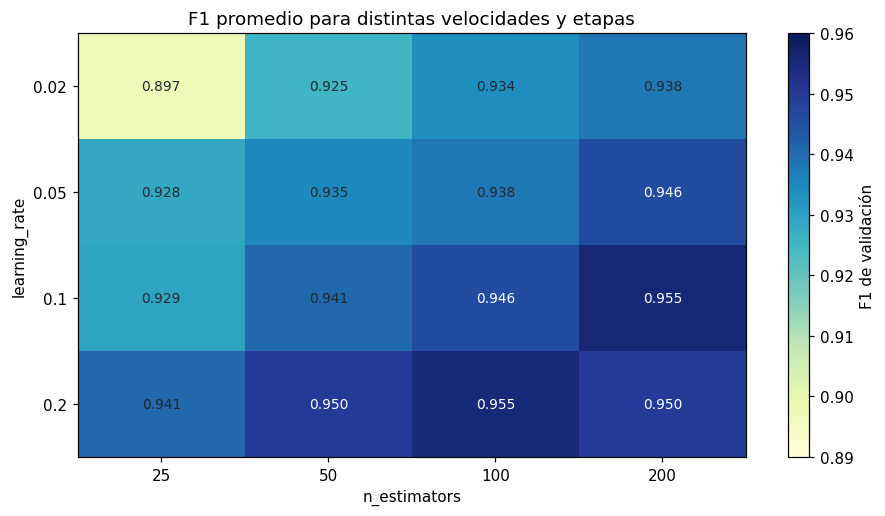

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

imagen = ax.imshow(
    tabla_tasa_estimadores.values,
    cmap="YlGnBu",
    vmin=0.89,
    vmax=0.96,
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(tabla_tasa_estimadores.columns))
)
ax.set_xticklabels(tabla_tasa_estimadores.columns)
ax.set_yticks(
    np.arange(len(tabla_tasa_estimadores.index))
)
ax.set_yticklabels(tabla_tasa_estimadores.index)
ax.set_xlabel("n_estimators")
ax.set_ylabel("learning_rate")
ax.set_title(
    "F1 promedio para distintas velocidades y etapas"
)

for fila in range(
    len(tabla_tasa_estimadores.index)
):
    for columna in range(
        len(tabla_tasa_estimadores.columns)
    ):
        valor = tabla_tasa_estimadores.iloc[
            fila, columna
        ]
        color = (
            "white"
            if valor >= 0.945
            else "#1F2933"
        )
        ax.text(
            columna,
            fila,
            f"{valor:.3f}",
            ha="center",
            va="center",
            color=color,
            fontsize=9,
        )

fig.colorbar(
    imagen,
    ax=ax,
    label="F1 de validación",
)
plt.tight_layout()
plt.show()


Con `learning_rate=0,02`, pasar de 25 a 200 árboles eleva el F1 promedio de `0,897` a `0,938`: las correcciones eran pequeñas y necesitaban más etapas. La mejor celda de esta tabla usa `learning_rate=0,10` y 200 árboles, con F1 `0,955`.

Una tasa mayor no mejora indefinidamente. Con `learning_rate=0,20`, el resultado sube hasta `0,955` con 100 árboles y luego baja a `0,950` con 200. No existe una cantidad universalmente correcta: la tasa y el número de árboles deben analizarse juntos.


## 8. Controlar la complejidad de las correcciones

Además de la cantidad y el peso de los árboles, importa qué tan compleja es cada corrección. Compararemos configuraciones deliberadamente distintas:

- pocos pasos y correcciones muy pequeñas;
- aprendizaje gradual con árboles de profundidad `2`;
- árboles profundos y flexibles;
- una variante estocástica con `subsample=0.8`;
- hojas más amplias mediante `min_samples_leaf=10`.

Seguiremos usando solamente validación cruzada sobre desarrollo.


In [15]:
configuraciones = {
    "Pasos insuficientes": {
        "n_estimators": 25,
        "learning_rate": 0.02,
        "max_depth": 1,
        "subsample": 1.0,
    },
    "Aprendizaje gradual": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "subsample": 1.0,
    },
    "Árboles profundos": {
        "n_estimators": 200,
        "learning_rate": 0.10,
        "max_depth": 5,
        "subsample": 1.0,
    },
    "Boosting estocástico": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "subsample": 0.8,
    },
    "Hojas más amplias": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 1.0,
    },
}

filas_control = []

for nombre, parametros in configuraciones.items():
    resultados = cross_validate(
        GradientBoostingClassifier(
            random_state=42,
            **parametros,
        ),
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
        return_train_score=True,
        n_jobs=-1,
    )

    filas_control.append({
        "configuracion": nombre,
        "F1_entrenamiento": (
            resultados["train_score"].mean()
        ),
        "F1_validacion": (
            resultados["test_score"].mean()
        ),
        "desviacion_F1": (
            resultados["test_score"].std()
        ),
        "brecha": (
            resultados["train_score"].mean()
            - resultados["test_score"].mean()
        ),
    })

resultados_control = pd.DataFrame(filas_control)


In [16]:
resultados_control.sort_values(
    "F1_validacion",
    ascending=False,
).round(4)


,configuracion,F1_entrenamiento,F1_validacion,desviacion_F1,brecha
3,Boosting estocástico,1.0000,0.9588,0.0278,0.0412
4,Hojas más amplias,1.0000,0.9585,0.0348,0.0415
1,Aprendizaje gradual,1.0000,0.9462,0.0241,0.0538
2,Árboles profundos,1.0000,0.9237,0.0401,0.0763
0,Pasos insuficientes,0.8622,0.8301,0.0461,0.0321


La configuración con pasos insuficientes obtiene F1 `0,830`: las correcciones son demasiado pocas y demasiado pequeñas. Los árboles profundos ajustan perfectamente el entrenamiento, pero su validación baja a `0,924`, una señal de que la flexibilidad adicional no ayudó en este caso.

El boosting estocástico alcanza el mayor promedio, `0,959`, seguido muy de cerca por las hojas amplias, con `0,959` al redondear. La diferencia real entre ambos es menor que `0,001` y no permite declarar un ganador general. La tabla sirve para comprender controles de complejidad, no para convertir diferencias minúsculas en certezas.


## 9. Ver cómo aparece el sobreajuste

Para observar el riesgo con claridad, crearemos un problema sintético más ruidoso. Usaremos una división interna de entrenamiento y validación y un modelo flexible de 500 etapas.

`staged_predict()` permite recuperar la clasificación acumulada después de cada árbol. Así podemos medir cómo cambia F1 mientras el modelo continúa agregando correcciones.


In [17]:
X_ruido, y_ruido = make_classification(
    n_samples=1200,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    weights=[0.62, 0.38],
    class_sep=0.75,
    flip_y=0.14,
    random_state=42,
)

(
    X_ruido_train,
    X_ruido_validacion,
    y_ruido_train,
    y_ruido_validacion,
) = train_test_split(
    X_ruido,
    y_ruido,
    test_size=0.30,
    random_state=42,
    stratify=y_ruido,
)

modelo_largo = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.08,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42,
)
modelo_largo.fit(X_ruido_train, y_ruido_train)

filas_etapas = []

for etapa, (
    pred_train,
    pred_validacion,
) in enumerate(
    zip(
        modelo_largo.staged_predict(X_ruido_train),
        modelo_largo.staged_predict(
            X_ruido_validacion
        ),
    ),
    start=1,
):
    filas_etapas.append({
        "etapa": etapa,
        "F1_entrenamiento": f1_score(
            y_ruido_train,
            pred_train,
        ),
        "F1_validacion": f1_score(
            y_ruido_validacion,
            pred_validacion,
        ),
    })

resultados_etapas = pd.DataFrame(filas_etapas)
mejor_etapa = resultados_etapas.loc[
    resultados_etapas["F1_validacion"].idxmax()
]

pd.DataFrame({
    "momento": [
        "Mejor validación",
        "Última etapa",
    ],
    "etapa": [
        int(mejor_etapa["etapa"]),
        int(resultados_etapas.iloc[-1]["etapa"]),
    ],
    "F1_entrenamiento": [
        mejor_etapa["F1_entrenamiento"],
        resultados_etapas.iloc[-1][
            "F1_entrenamiento"
        ],
    ],
    "F1_validacion": [
        mejor_etapa["F1_validacion"],
        resultados_etapas.iloc[-1][
            "F1_validacion"
        ],
    ],
}).round(4)


,momento,etapa,F1_entrenamiento,F1_validacion
0,Mejor validación,202,0.971,0.7126
1,Última etapa,500,1.000,0.6899


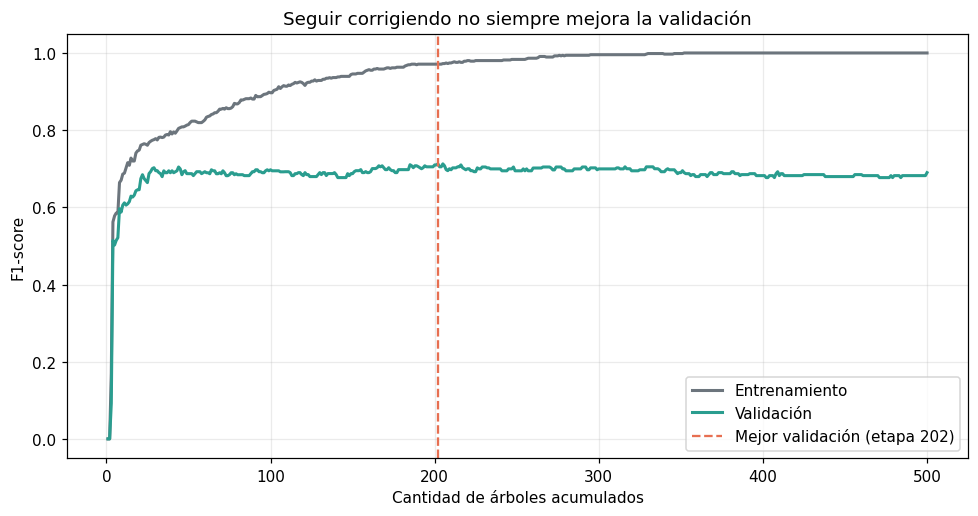

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    resultados_etapas["etapa"],
    resultados_etapas["F1_entrenamiento"],
    color="#6C757D",
    linewidth=2,
    label="Entrenamiento",
)
ax.plot(
    resultados_etapas["etapa"],
    resultados_etapas["F1_validacion"],
    color="#2A9D8F",
    linewidth=2,
    label="Validación",
)
ax.axvline(
    mejor_etapa["etapa"],
    color="#E76F51",
    linestyle="--",
    label=(
        "Mejor validación "
        f"(etapa {int(mejor_etapa['etapa'])})"
    ),
)

ax.set_xlabel("Cantidad de árboles acumulados")
ax.set_ylabel("F1-score")
ax.set_title(
    "Seguir corrigiendo no siempre mejora la validación"
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


En este ejemplo, el F1 de validación alcanza su máximo de `0,713` alrededor de la etapa `202`. El entrenamiento todavía no es perfecto en ese punto. Al llegar a 500 árboles, el F1 de entrenamiento sube a `1,000`, pero la validación baja a `0,690`.

El modelo continuó corrigiendo los casos conocidos, pero parte de esas correcciones se adaptó al ruido. La etapa 202 no es una regla reutilizable ni una selección para el problema médico: es una demostración de por qué más árboles no significan automáticamente mejor generalización.


## 10. Elegir una configuración sin mirar el test

Entre las configuraciones evaluadas sobre el problema médico, el boosting estocástico obtuvo el mayor F1 promedio. Lo usaremos como modelo final.

La ventaja sobre la alternativa de hojas amplias es mínima. Elegir cualquiera de las dos sería defendible. Lo metodológicamente importante es que la decisión se tomó con validación sobre desarrollo, antes de consultar el test.


In [19]:
parametros_elegidos = configuraciones[
    "Boosting estocástico"
]

modelo_final = GradientBoostingClassifier(
    random_state=42,
    **parametros_elegidos,
)

pd.DataFrame({
    "hiperparametro": list(
        parametros_elegidos.keys()
    ),
    "valor": list(
        parametros_elegidos.values()
    ),
})


,hiperparametro,valor
0,n_estimators,200.00
1,learning_rate,0.05
2,max_depth,2.00
3,subsample,0.80


## 11. Evaluar una vez sobre el test final

Ahora que la configuración quedó fijada, entrenaremos con todo el conjunto de desarrollo y consultaremos el test reservado una única vez.


In [20]:
modelo_final.fit(X_desarrollo, y_desarrollo)
prediccion_final = modelo_final.predict(
    X_test_final
)

metricas_finales = pd.DataFrame({
    "metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
    "valor": [
        accuracy_score(
            y_test_final,
            prediccion_final,
        ),
        precision_score(
            y_test_final,
            prediccion_final,
        ),
        recall_score(
            y_test_final,
            prediccion_final,
        ),
        f1_score(
            y_test_final,
            prediccion_final,
        ),
    ],
})

metricas_finales.round(4)


,metrica,valor
0,Accuracy,0.9737
1,Precision,1.0000
2,Recall,0.9286
3,F1-score,0.9630


array([[72,  0],
       [ 3, 39]])

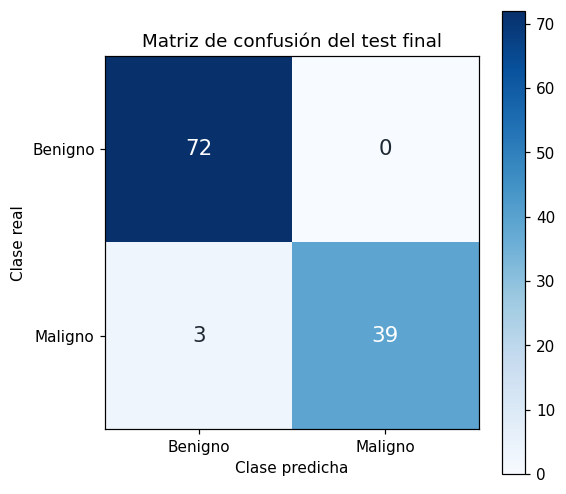

In [21]:
matriz_final = confusion_matrix(
    y_test_final,
    prediccion_final,
)

fig, ax = plt.subplots(figsize=(5.4, 4.8))

imagen = ax.imshow(
    matriz_final,
    cmap="Blues",
)

for fila in range(2):
    for columna in range(2):
        valor = matriz_final[fila, columna]
        color = (
            "white"
            if valor > matriz_final.max() / 2
            else "#1F2933"
        )
        ax.text(
            columna,
            fila,
            str(valor),
            ha="center",
            va="center",
            color=color,
            fontsize=14,
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benigno", "Maligno"])
ax.set_yticklabels(["Benigno", "Maligno"])
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión del test final")
fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

matriz_final


El modelo obtiene accuracy `0,974` y F1 `0,963`. Clasifica correctamente 72 casos benignos y 39 malignos. No produce falsas alarmas, pero deja sin detectar tres casos malignos, por lo que el recall es `0,929`.

El resultado es sólido para este ejercicio, pero no convierte al modelo en una herramienta clínica ni demuestra superioridad universal. La muestra es pequeña, la evaluación depende del contexto y tres falsos negativos pueden tener un costo importante. Una métrica alta no reemplaza el análisis de errores.


## 12. Conocer una implementación basada en histogramas

`scikit-learn` también ofrece `HistGradientBoostingClassifier`. Agrupa valores numéricos en intervalos para acelerar muchos problemas tabulares y dispone de controles propios.

Haremos una comparación breve usando los mismos folds y las configuraciones predeterminadas. No es una competencia definitiva: para comparar implementaciones con justicia habría que ajustar cada una con el mismo cuidado y medir también costo, memoria y necesidades de preprocesamiento.


In [22]:
implementaciones_sklearn = {
    "GradientBoosting clásico": (
        GradientBoostingClassifier(
            random_state=42,
        )
    ),
    "HistGradientBoosting": (
        HistGradientBoostingClassifier(
            random_state=42,
        )
    ),
}

filas_implementaciones = []

for nombre, modelo in (
    implementaciones_sklearn.items()
):
    puntajes = cross_val_score(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )
    filas_implementaciones.append({
        "implementacion": nombre,
        "F1_promedio": puntajes.mean(),
        "desviacion_F1": puntajes.std(),
    })

pd.DataFrame(
    filas_implementaciones
).round(4)


,implementacion,F1_promedio,desviacion_F1
0,GradientBoosting clásico,0.9431,0.0305
1,HistGradientBoosting,0.9550,0.0298


Con sus valores predeterminados, la versión clásica obtiene F1 `0,943` y la versión basada en histogramas `0,955`. Esa diferencia ilustra que las implementaciones no son idénticas, pero no autoriza a declarar una ganadora: ninguna recibió el mismo proceso de ajuste que el modelo final.

Fuera de `scikit-learn`, **XGBoost**, **LightGBM** y **CatBoost** ofrecen implementaciones populares y muy optimizadas. No las instalaremos en este cuaderno. Primero importa comprender boosting; después puede estudiarse qué aporta cada biblioteca.


## 13. Actividad breve

La siguiente celda compara cuatro combinaciones modificables. Mantiene 150 árboles de profundidad `2` y explora dos tasas de aprendizaje y dos proporciones de muestreo. Todo se evalúa con tres folds sobre desarrollo.


In [23]:
tasas_actividad = [0.03, 0.08]
subsamples_actividad = [0.7, 1.0]

cv_actividad = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=11,
)
filas_actividad = []

for tasa in tasas_actividad:
    for proporcion in subsamples_actividad:
        puntajes = cross_val_score(
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=tasa,
                max_depth=2,
                subsample=proporcion,
                random_state=42,
            ),
            X_desarrollo,
            y_desarrollo,
            cv=cv_actividad,
            scoring="f1",
            n_jobs=-1,
        )
        filas_actividad.append({
            "learning_rate": tasa,
            "subsample": proporcion,
            "F1_promedio": puntajes.mean(),
            "desviacion_F1": puntajes.std(),
        })

pd.DataFrame(filas_actividad).round(4)


,learning_rate,subsample,F1_promedio,desviacion_F1
0,0.03,0.7,0.9441,0.0158
1,0.03,1.0,0.9383,0.0129
2,0.08,0.7,0.9554,0.0076
3,0.08,1.0,0.9532,0.0041


Podés continuar la actividad de estas maneras:

- agregá `0.15` a `tasas_actividad`;
- probá `max_depth=1` y `max_depth=3`;
- cambiá 150 por 50 y por 300 árboles;
- incorporá `min_samples_leaf=10`;
- explicá si una diferencia pequeña justifica elegir una configuración más compleja.

No vuelvas a usar el test para decidir. La actividad debe resolverse mediante validación sobre el conjunto de desarrollo.


## 14. Ventajas y limitaciones

Gradient Boosting puede capturar relaciones no lineales e interacciones y suele funcionar muy bien con datos tabulares. Al estar basado en árboles, no necesita escalado numérico. La tasa de aprendizaje, la profundidad, el tamaño de las hojas y el muestreo permiten controlar su flexibilidad.

El costo es una mayor sensibilidad a la configuración. Los árboles dependen de los anteriores, por lo que el entrenamiento es secuencial y no se paraleliza de la misma manera que Random Forest. Una cantidad excesiva de etapas o correcciones demasiado complejas puede adaptar el modelo al ruido.

También es menos interpretable que un árbol pequeño y no resuelve problemas metodológicos. Puede aprovechar con gran eficacia una variable con fuga de datos. Tampoco extrapola bien fuera de los patrones observados en regresión. Si un modelo más simple obtiene resultados parecidos y la explicación es prioritaria, la alternativa simple puede seguir siendo preferible.


## 15. Síntesis

En este cuaderno:

- construimos una predicción inicial y cuatro correcciones sucesivas;
- reconstruimos manualmente una predicción de regresión;
- distinguimos la secuencia de boosting de la votación de Random Forest;
- comparamos árbol, bosque y boosting mediante los mismos folds;
- estudiamos la interacción entre `learning_rate` y `n_estimators`;
- analizamos profundidad, tamaño de hojas y `subsample`;
- observamos subajuste por correcciones insuficientes;
- mostramos sobreajuste al continuar corrigiendo datos ruidosos;
- elegimos una configuración sin consultar el test;
- realizamos una única evaluación final;
- presentamos brevemente HistGradientBoosting y otras implementaciones.

Gradient Boosting no construye de una vez un árbol capaz de resolver todo. Forma un modelo potente mediante muchas correcciones pequeñas. Su fortaleza depende de saber cuándo, cuánto y con qué complejidad corregir.


## Para pensar

1. ¿Por qué un árbol de Gradient Boosting no debe interpretarse como una predicción completa e independiente?
2. ¿Qué relación existe entre `learning_rate` y `n_estimators`?
3. ¿Cómo distinguirías pasos insuficientes de sobreajuste al comparar entrenamiento y validación?
4. ¿Por qué un resultado levemente superior en validación no siempre justifica elegir una configuración más compleja?
5. ¿En qué situación preferirías Random Forest o un modelo más simple aunque Gradient Boosting obtuviera una métrica algo mayor?
